In [221]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

df = pd.read_csv("../data/adult.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [222]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [223]:
df.isna().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [224]:
df.dropna(inplace=True)

In [225]:
df.duplicated().sum()

np.int64(52)

In [226]:
df.drop_duplicates(inplace=True)

In [227]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48790.0,38.652798,13.708493,17.0,28.0,37.0,48.00,90.0
fnlwgt,48790.0,189668.999365,105617.231232,12285.0,117555.0,178138.5,237606.25,1490400.0
educational-num,48790.0,10.078807,2.570046,1.0,9.0,10.0,12.00,16.0
capital-gain,48790.0,1080.217688,7455.905921,0.0,0.0,0.0,0.00,99999.0
capital-loss,48790.0,87.595573,403.209129,0.0,0.0,0.0,0.00,4356.0
hours-per-week,48790.0,40.425886,12.392729,1.0,40.0,40.0,45.00,99.0


In [228]:
df.describe(include="object").T

,count,unique,top,freq
workclass,48790,9,Private,33860
education,48790,16,HS-grad,15770
marital-status,48790,7,Married-civ-spouse,22366
occupation,48790,15,Prof-specialty,6165
relationship,48790,6,Husband,19703
race,48790,5,White,41714
gender,48790,2,Male,32614
native-country,48790,42,United-States,43792
income,48790,2,<=50K,37109


In [229]:
num_cols = df.select_dtypes("number").columns.to_list()
cat_cols = df.select_dtypes("object").columns.to_list()

print(f"Num: {num_cols}")
print(f"Cat: {cat_cols}")

Num: ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Cat: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'income']


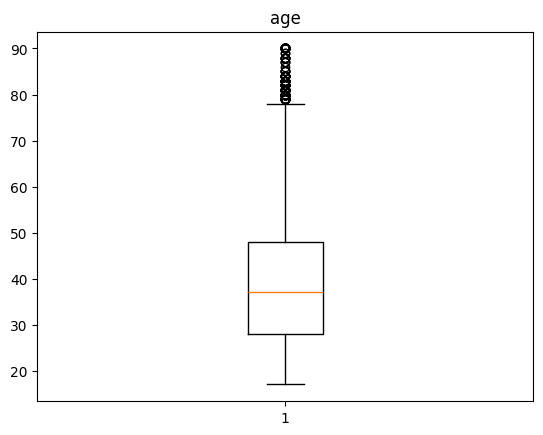

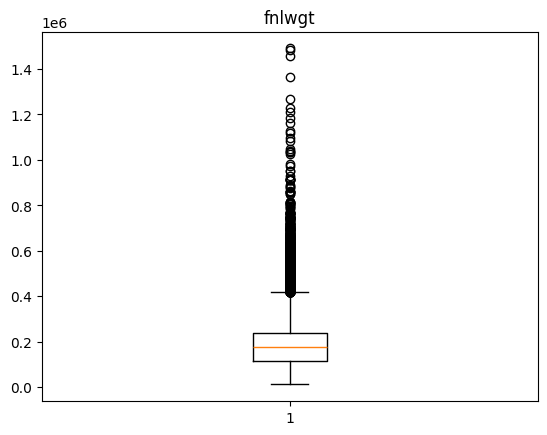

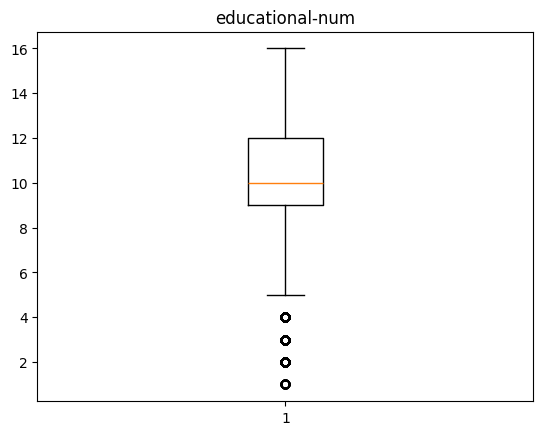

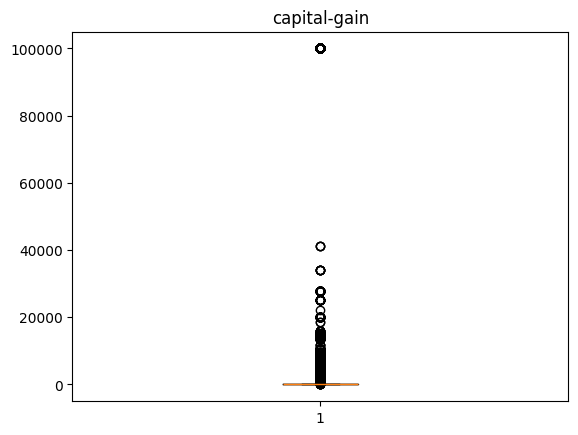

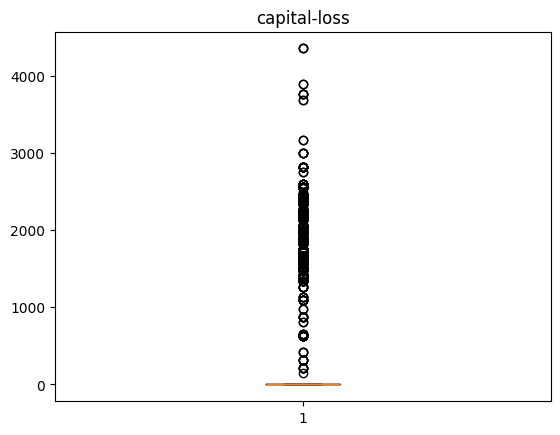

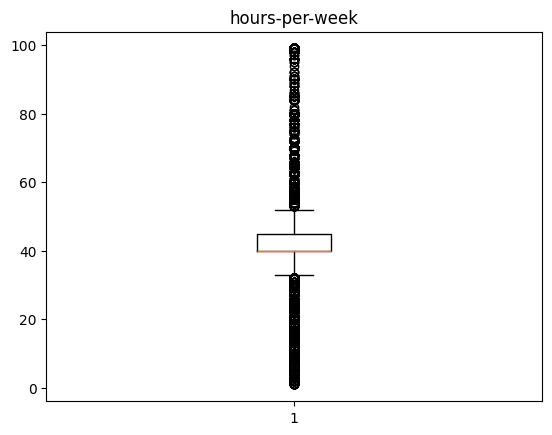

In [230]:
for col in num_cols:
    plt.title(col)
    plt.boxplot(x=df[col])
    plt.show()

In [231]:
for col in cat_cols:
    print(f"{col} : {df[col].unique()}")

workclass : ['Private' 'Local-gov' '?' 'Self-emp-not-inc' 'Federal-gov' 'State-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
education : ['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' '10th' 'Prof-school'
 '7th-8th' 'Bachelors' 'Masters' 'Doctorate' '5th-6th' 'Assoc-voc' '9th'
 '12th' '1st-4th' 'Preschool']
marital-status : ['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']
occupation : ['Machine-op-inspct' 'Farming-fishing' 'Protective-serv' '?'
 'Other-service' 'Prof-specialty' 'Craft-repair' 'Adm-clerical'
 'Exec-managerial' 'Tech-support' 'Sales' 'Priv-house-serv'
 'Transport-moving' 'Handlers-cleaners' 'Armed-Forces']
relationship : ['Own-child' 'Husband' 'Not-in-family' 'Unmarried' 'Wife' 'Other-relative']
race : ['Black' 'White' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']
gender : ['Male' 'Female']
native-country : ['United-States' '?' 'Peru' 'Guatemala' 'Mexico' 'Dominican-Republic'
 'Ireland' 'Germany

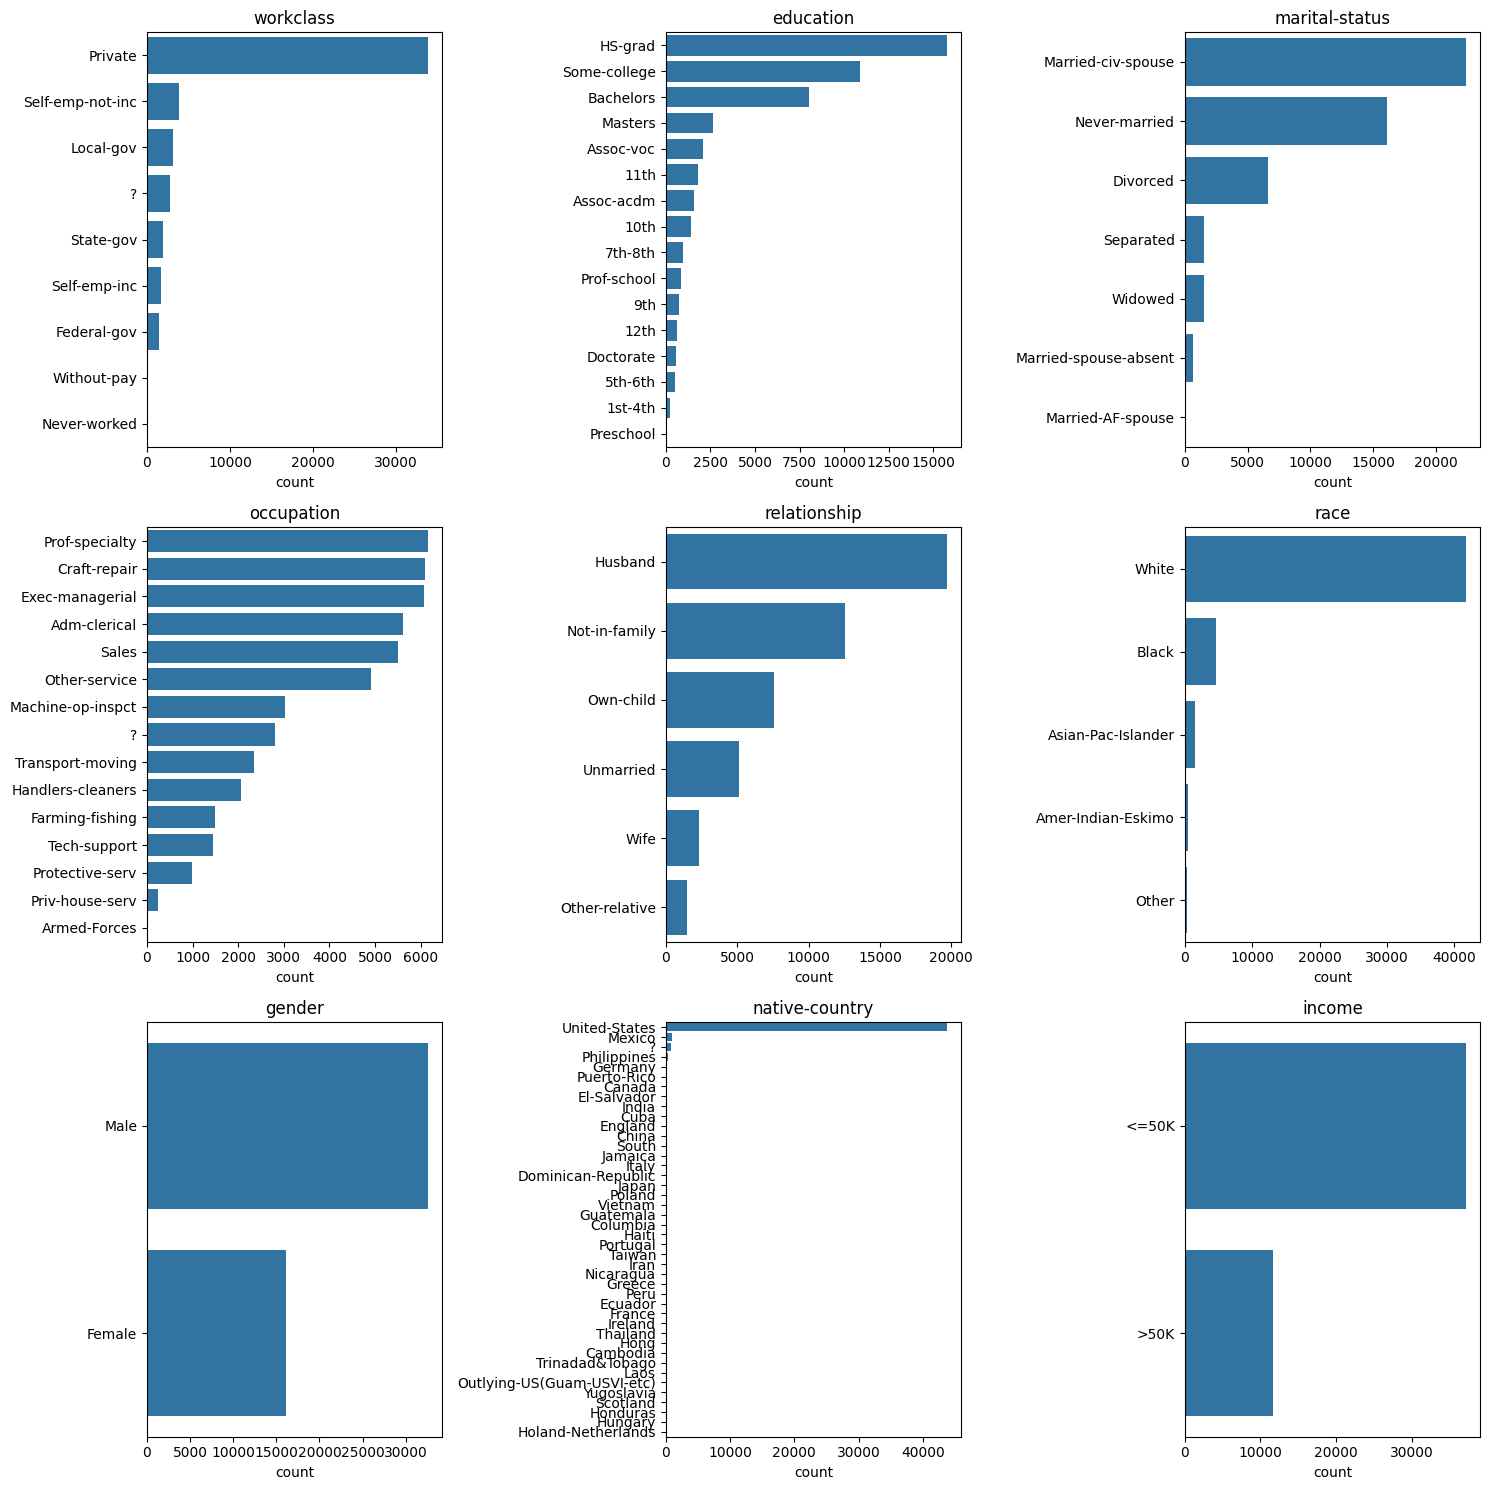

In [232]:
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
ax = ax.flatten()

for i, col in enumerate(cat_cols):
    ax[i].set_title(col)
    sns.countplot(
        data=df,
        y=col,
        ax=ax[i],
        order=df[col].value_counts().index
    )
    ax[i].set_ylabel(None)

for j in range(len(cat_cols), n_rows*n_cols):
    fig.delaxes(ax[j])
    
plt.tight_layout()
plt.show()

In [233]:
df_clean = df.drop(columns=["native-country", "race"])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48790 non-null  int64 
 1   workclass        48790 non-null  object
 2   fnlwgt           48790 non-null  int64 
 3   education        48790 non-null  object
 4   educational-num  48790 non-null  int64 
 5   marital-status   48790 non-null  object
 6   occupation       48790 non-null  object
 7   relationship     48790 non-null  object
 8   gender           48790 non-null  object
 9   capital-gain     48790 non-null  int64 
 10  capital-loss     48790 non-null  int64 
 11  hours-per-week   48790 non-null  int64 
 12  income           48790 non-null  object
dtypes: int64(6), object(7)
memory usage: 5.2+ MB


### Encoding

In [234]:
def encode_labels(df: pd.DataFrame):
    unq_struct = dict()
    for col in df.select_dtypes("object").columns:
        unq = df[col].unique()
        unq_struct[col] = {v: k for k, v in enumerate(unq)}
        df[col] = df[col].map(unq_struct[col])

    return df, unq_struct

df_enc, struct = encode_labels(df_clean)
df_enc.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,income
0,25,0,226802,0,7,0,0,0,0,0,0,40,0
1,38,0,89814,1,9,1,1,1,0,0,0,50,0
2,28,1,336951,2,12,1,2,1,0,0,0,40,1
3,44,0,160323,3,10,1,0,1,0,7688,0,40,1
4,18,2,103497,3,10,0,3,0,1,0,0,30,0


In [235]:
struct

{'workclass': {'Private': 0,
  'Local-gov': 1,
  '?': 2,
  'Self-emp-not-inc': 3,
  'Federal-gov': 4,
  'State-gov': 5,
  'Self-emp-inc': 6,
  'Without-pay': 7,
  'Never-worked': 8},
 'education': {'11th': 0,
  'HS-grad': 1,
  'Assoc-acdm': 2,
  'Some-college': 3,
  '10th': 4,
  'Prof-school': 5,
  '7th-8th': 6,
  'Bachelors': 7,
  'Masters': 8,
  'Doctorate': 9,
  '5th-6th': 10,
  'Assoc-voc': 11,
  '9th': 12,
  '12th': 13,
  '1st-4th': 14,
  'Preschool': 15},
 'marital-status': {'Never-married': 0,
  'Married-civ-spouse': 1,
  'Widowed': 2,
  'Divorced': 3,
  'Separated': 4,
  'Married-spouse-absent': 5,
  'Married-AF-spouse': 6},
 'occupation': {'Machine-op-inspct': 0,
  'Farming-fishing': 1,
  'Protective-serv': 2,
  '?': 3,
  'Other-service': 4,
  'Prof-specialty': 5,
  'Craft-repair': 6,
  'Adm-clerical': 7,
  'Exec-managerial': 8,
  'Tech-support': 9,
  'Sales': 10,
  'Priv-house-serv': 11,
  'Transport-moving': 12,
  'Handlers-cleaners': 13,
  'Armed-Forces': 14},
 'relationshi

### Split

In [236]:
def train_test_split(X, y, test_size=0.2, random_state=None):
    if random_state:
        np.random.seed(random_state)
    
    n_sample = len(X)
    shuffle_indices = np.random.permutation(np.arange(n_sample))

    test_size = round(n_sample * test_size)
    train_size = n_sample - test_size

    train_indices = shuffle_indices[:train_size]
    test_indices = shuffle_indices[test_size:]

    X_train, X_test = X.iloc[train_indices], X.iloc[test_indices]
    y_train, y_test = y.iloc[train_indices], y.iloc[test_indices]

    return [X_train, X_test, y_train, y_test]

In [237]:
X = df_enc.drop(columns=["income"])
y = df_enc.income

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### Scaling

In [238]:
def min_max_scaler(X: pd.DataFrame):
    return ((X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)))

def std_scaler(X:pd.DataFrame):
    return ((X - X.mean(axis=0)) / X.std(axis=0))

In [239]:
X_train_mm_scaler = min_max_scaler(X_train)
X_test_mm_scaler = min_max_scaler(X_test)
X_train_mm_scaler.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week
3169,0.506849,0.625,0.154148,0.200000,0.600000,0.166667,0.500000,0.2,0.0,0.000000,0.0,0.397959
25270,0.356164,0.000,0.032407,0.466667,0.800000,0.500000,0.714286,0.6,0.0,0.000000,0.0,0.438776
33668,0.164384,0.000,0.082457,0.466667,0.800000,0.000000,0.357143,0.4,0.0,0.086141,0.0,0.448980
29925,0.410959,0.000,0.122025,0.466667,0.800000,0.166667,0.714286,0.2,0.0,0.000000,0.0,0.397959
11098,0.397260,0.000,0.007647,0.066667,0.533333,0.500000,0.142857,0.4,0.0,0.000000,0.0,0.397959


In [240]:
X_train_std_scaler = std_scaler(X_train)
X_test_std_scaler = std_scaler(X_test)
X_train_std_scaler.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week
3169,1.113558,2.388777,0.475179,-0.317811,-0.028856,-0.100955,0.175420,-0.485554,-0.701819,-0.145893,-0.217294,-0.034178
25270,0.312906,-0.560678,-1.230389,0.845402,1.137500,1.595331,1.086488,1.188589,-0.701819,-0.145893,-0.217294,0.288893
33668,-0.706105,-0.560678,-0.529199,0.845402,1.137500,-0.949098,-0.431959,0.351518,-0.701819,1.008254,-0.217294,0.369660
29925,0.604052,-0.560678,0.025140,0.845402,1.137500,-0.100955,1.086488,-0.485554,-0.701819,-0.145893,-0.217294,-0.034178
11098,0.531266,-0.560678,-1.577260,-0.899417,-0.417641,1.595331,-1.343027,0.351518,-0.701819,-0.145893,-0.217294,-0.034178


### Make Model

In [241]:
class KNN:
    def __init__(self, k:int, p:int):
        self.k = k
        self.p = p
    
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def _minkowski_distance(self, x, y):
        return np.power(np.sum(np.abs(x - y) ** self.p), 1 / self.p)

    def _get_nn(self, X_test):
        distances = [self._minkowski_distance(X_test, train) for train in self.X_train]
        k_idxs = np.argsort(distances)[:self.k]
        kn_labels = [self.y_train[i] for i in k_idxs]
        return np.bincount(kn_labels).argmax()
    
    def predict(self, X_test):
        preds = [self._get_nn(x) for x in X_test]
        return np.array(preds)

### Evaluation Model

In [242]:
class EvaluationModel:
    def __init__(self, y_true, y_pred):
        self.y_true = y_true
        self.y_pred = y_pred

    def accuracy(self, y_pred, y_true):
        return np.sum(y_pred == y_true) / len(y_true)
    
    def precision(self, TP, FP):
        return TP / (TP + FP) if (TP + FP) != 0 else 0
    
    def recall(self, TP, FN):
        return TP / (TP + FN) if (TP + FN) != 0 else 0
    
    def f1_score(self, TP, FP, FN):
        P = self.precision(TP, FP)
        R = self.precision(TP, FN)

        return 2 * (P*R) / (P+R) if (P+R) != 0 else 0
    
    def make_report(self):
        cats = pd.Series(self.y_true).unique()

        report = {"categories": [], "precision": [], "recall": [], "f1-score": []}

        for cat in cats:
            # Confusion Matrix
            TP = np.sum((self.y_true == cat) & (self.y_pred == cat)) # Asli positif di prediksi positif
            TN = np.sum((self.y_true != cat) & (self.y_pred != cat)) # Asli negatif di prediksi negatif
            FP = np.sum((self.y_true != cat) & (self.y_pred == cat)) # Asli negatif di prediksi positif
            FN = np.sum((self.y_true == cat) & (self.y_pred != cat)) # Asli positif di prediksi negatif

            # Calculation Matrix
            P = self.precision(TP, FP)
            R = self.recall(TP, FN)
            F1 = self.f1_score(TP, FP, FN)

            # Add to report
            report["categories"].append(cat)
            report["precision"].append(P)
            report["recall"].append(R)
            report["f1-score"].append(F1)
        
        accuracy = self.accuracy(self.y_pred, self.y_true)
        results = pd.DataFrame(report)

        return accuracy, results

In [243]:
from IPython.display import display 

def search_good_model(params: dict):
    models = list()

    for k in params["K"]:
        for p in params["P"]:
            for i, (train, test) in enumerate(params["scaler"]):
                model = KNN(k=k, p=p)
                model.fit(train[:1000].to_numpy(), y_train[:1000].to_numpy())

                preds = model.predict(test[:1000].to_numpy())

                eval_model = EvaluationModel(preds, y_test[:1000].to_numpy())
                accuracy, report = eval_model.make_report()

                models.append({
                    "params": {"K": k, "P": p, "Scaler": i},
                    "accuracy": accuracy,
                    "report": report
                })

    best_model = sorted(models, reverse=True, key=lambda x: x["accuracy"])

    for model in best_model:
        print(f"Accuracy: {model["accuracy"]}")
        print(f"Params: {model["params"]}")
        display(model["report"])

In [244]:
def distance_callback(d):
    return 1 / (d**2 + 1e-5)

params = {
    "K": range(2, 10),
    "P": range(1, 3),
    "scaler": [(X_train_mm_scaler, X_test_mm_scaler), (X_train_std_scaler, X_test_std_scaler), (X_train, X_test)],
}

search_good_model(params)

Accuracy: 0.815
Params: {'K': 8, 'P': 1, 'Scaler': 1}


,categories,precision,recall,f1-score
0,0,0.941333,0.833530,0.884158
1,1,0.436000,0.712418,0.540943


Accuracy: 0.814
Params: {'K': 5, 'P': 1, 'Scaler': 0}


,categories,precision,recall,f1-score
0,0,0.906667,0.854271,0.879690
1,1,0.536000,0.656863,0.590308


Accuracy: 0.814
Params: {'K': 9, 'P': 1, 'Scaler': 1}


...

,categories,precision,recall,f1-score
0,0,0.958667,0.771459,0.854935
1,1,0.148000,0.544118,0.232704


Accuracy: 0.737
Params: {'K': 3, 'P': 1, 'Scaler': 2}


,categories,precision,recall,f1-score
0,0,0.908,0.778286,0.838154
1,1,0.224,0.448000,0.298667


Accuracy: 0.737
Params: {'K': 3, 'P': 2, 'Scaler': 2}


,categories,precision,recall,f1-score
0,0,0.912,0.776390,0.838749
1,1,0.212,0.445378,0.287263
